### 3.1 - Clasificación con KNN
KNN: k-nearest neighbors o k vecinos cercanos o K vecinos próximos

1. Importamos los datos

In [6]:
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")

## Importo el archivo
inscritos = pd.read_excel("/content/drive/MyDrive/Analitica/3. BD1-GymData.xlsx")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Limpieza de datos


In [7]:
inscritos.shape

(1000, 4)

In [8]:
### Elimino las filas donde "Enroll" está vacío
AAA = inscritos.dropna(subset=["Enroll"])

In [9]:
AAA.shape

(1000, 4)

In [10]:
## Se procede a inspeccionar las clases de la variable "PreApr"
AAA.groupby("Enroll").size()

,0
Enroll,
0,597
1,403


### 3. Descripción de las variables

In [11]:
import seaborn as sns

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


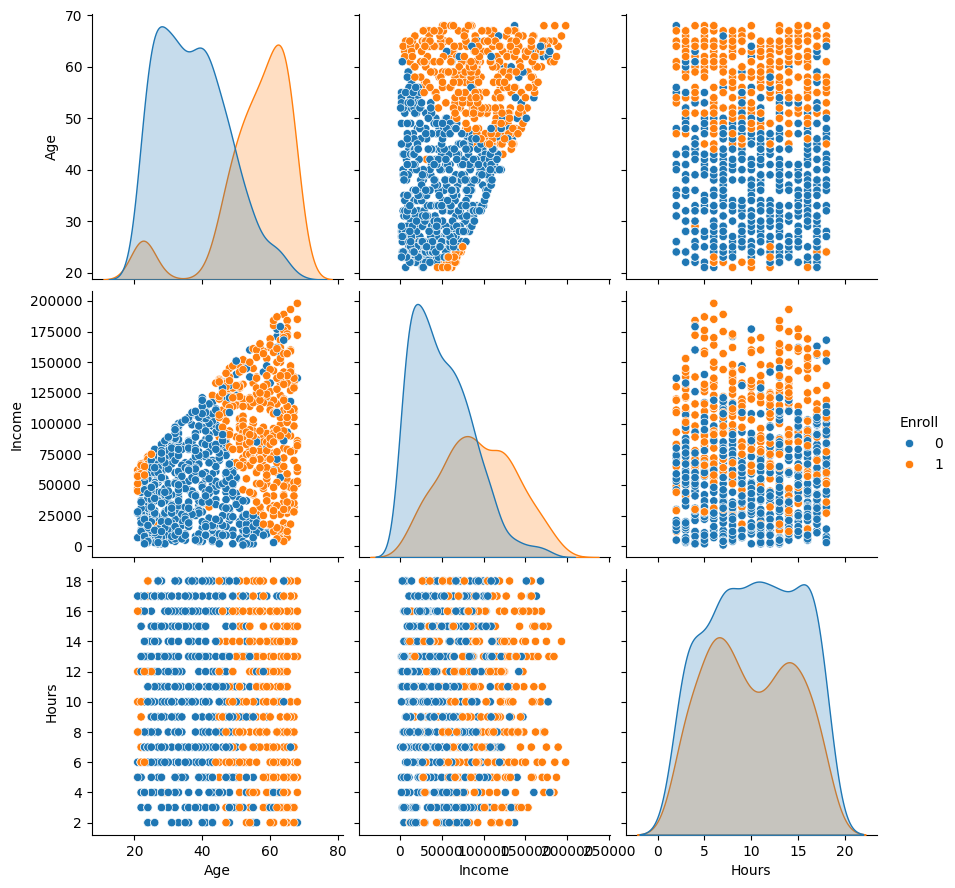

In [12]:
## Creamos nuestro dashboard
sns.pairplot(AAA, hue="Enroll", size=3, vars=["Age", "Income", "Hours"])

# Descripción de las variables correspondientes:


*  Age: edad de las personas
*  Income: ingresos de las personas
*  Hours: tiempo que la persona hace ejercicio
*  Enroll: si la persona compró o se inscribio en el paquete


In [13]:
## Escojo las variables independientes del modelo
XD=AAA[["Age", "Income", "Hours"]]

In [14]:
## Guardo la variable dependiente
yd=AAA["Enroll"]

In [15]:
import numpy as np
## Creamos la matriz de correlación
dfinf=pd.DataFrame(np.column_stack((XD,yd)))
dfinf.columns=["Age", "Income", "Hours", "Enroll"]
dfinf.corr()

,Age,Income,Hours,Enroll
Age,1.000000,0.450562,-0.040133,0.644033
Income,0.450562,1.000000,-0.018196,0.476372
Hours,-0.040133,-0.018196,1.000000,-0.048184
Enroll,0.644033,0.476372,-0.048184,1.000000


<Axes: >

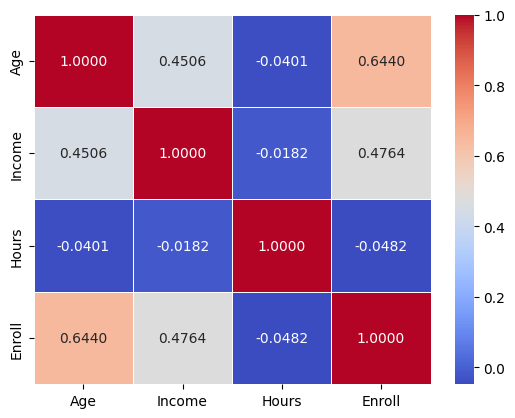

In [16]:
sns.heatmap(dfinf.corr(), cmap="coolwarm", linewidths=0.5, annot=True, fmt=".4f")

La edad es la variable que mejor lleva el proceso de caracterización de la inscripción de una persona al gym y las variables que tienen mayor correlación son Age e Income, debido a que Enroll es una variable dependiente.

In [17]:
dfinf.to_excel("Informe de inscritos.xlsx")

In [18]:
## Para exportar la matriz de correlación
dfCorrel = pd.DataFrame(dfinf.corr())
dfCorrel.to_excel("InformeCorrel.xlsx")

### 4.Implementación del modelo KNN

In [19]:
## Convierto los datasets a arrays
XDArray = np.array(XD, dtype=float)
ydArray = np.array(yd, dtype=float)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

## Creo la variable que aloja el modelo
knnModel = KNeighborsClassifier(n_neighbors=10)

In [21]:
## ENTRENO EL MODELO
knnModel.fit(XDArray, ydArray)

KNeighborsClassifier(n_neighbors=10)

Predecimos los yd

In [22]:
ydPred = knnModel.predict(XDArray)
ydPred

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 0.,
       0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0.,
       0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 1.,
       0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 1.,
       1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0.,
       0., 0., 1., 0., 1.

Métricas de evaluación del modelo

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yd,ydPred)  # Now confusion_matrix is defined
cm

array([[538,  59],
       [145, 258]])

In [24]:
## Exactitud (Accuracy)
## Número de predicciones correctas sobre el total de predicciones
exactitud = (cm[1][1] + cm[0][0])/cm.sum()
print(f"La exactitud (accuracy) del modelo es de {exactitud:.2%}")

La exactitud (accuracy) del modelo es de 79.60%


In [25]:
## TASA DE ERROR
## Número de predicciones incorrectas sobre el total de predicciones
# Opción 1
error = (cm[1][0] + cm[0][1])/cm.sum()
# Opción 2
error = 1 - exactitud
print(f"El error del modelo es de {error:.2%}")

El error del modelo es de 20.40%


In [26]:
## PRECISIÓN
## Que tan cerca está un resultado del valor verdadero. De los que calcula como verdaderos
## cuales son efectivamente verdaderos
precisión = cm[1][1]/(cm[1][1] + cm[0][1])
print(f"La precisión del modelo es de {precisión:.2%}")

La precisión del modelo es de 81.39%


In [27]:
## SENSIBILIDAD (RECALL)
## Es la cantidad de positivos bien clasificados por el modelo
## respecto al total de positivos
sensibilidad = cm[1][1]/(cm[1][1] + cm[1][0])
print(f"La sensibilidad del modelo es de {sensibilidad:.2%}")

La sensibilidad del modelo es de 64.02%


In [28]:
## ESPECIFICIDAD
## Es la cantidad de negativos bien clasificados por el modelo
## respecto al total de negativos
especificidad = cm[0][0]/(cm[0][1] + cm[0][0])
print(f"La especificidad del modelo es de {especificidad:.2%}")

La especificidad del modelo es de 90.12%


7. Pronóstico para un solo solicitante

In [29]:
## Evaluamos a una sola persona de los inscritos
XDi = np.array([(26,800,15)])
ydi = knnModel.predict(XDi)

print(f"La decisión frente al crédito es: {ydi}")

La decisión frente al crédito es: [0.]


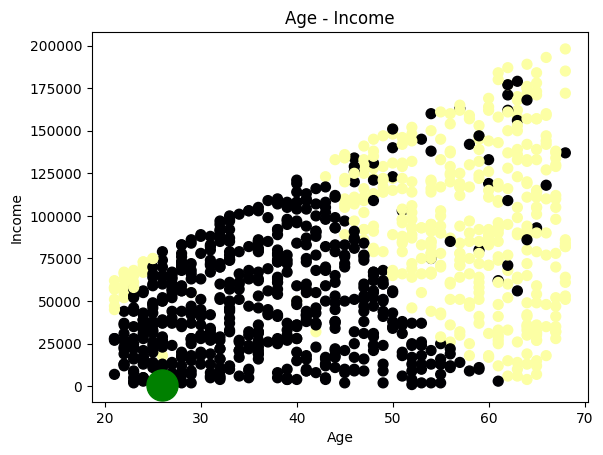

In [30]:
## Se grafica al solicitante de crédito (Age-Income)
import matplotlib.pyplot as plt

plt.scatter(XDArray[:,0], XDArray[:,1], c=ydArray, s=50, cmap="inferno")
plt.scatter(XDi[:,0],XDi[:,1], marker="o", s=500, facecolor="green")
plt.title("Age - Income")
plt.xlabel("Age"); plt.ylabel("Income")
plt.show()

## 3.2 - CLUSTERIZACIÓN CON KMEANS

In [31]:
from sklearn.cluster import KMeans
np.random.seed(42)
## Creamos 5 grupos de datos (clusters)
k=5
KMeansModel = KMeans(n_clusters=k, init="random", random_state=42)

In [32]:
## Entrenamos el modelo
KMeansModel.fit(XD.iloc[:,0:4], yd)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(init='random', n_clusters=5, random_state=42)

In [33]:
## Tomamos un solicitante y ubicamos el cluster en el que se encuentra (al que pertenece)
labels= KMeansModel.labels_
centroids = KMeansModel.cluster_centers_

XDi = np.array([(26,800,15)])
ydi = KMeansModel.predict(XDi)

print(f"Este solicitante pertenece al cluster {ydi}")

Este solicitante pertenece al cluster [3]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


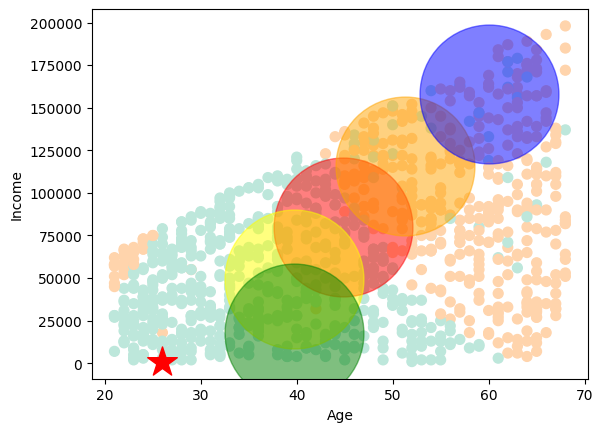

In [34]:
## Graficamos los clusters y ubicamos a este solicitante
plt.scatter(XDArray[:,0], XDArray[:,1], c=ydArray, s=50, cmap="icefire")
plt.scatter(XDi[:,0],XDi[:,1], marker="*", s=500, facecolor="red")

plt.scatter(centroids[0,0], centroids[0,1], marker="o", alpha=0.5, s=10000, facecolor="red")
plt.scatter(centroids[1,0], centroids[1,1], marker="o", alpha=0.5, s=10000, facecolor="yellow")
plt.scatter(centroids[2,0], centroids[2,1], marker="o", alpha=0.5, s=10000, facecolor="orange")
plt.scatter(centroids[3,0], centroids[3,1], marker="o", alpha=0.5, s=10000, facecolor="green")
plt.scatter(centroids[4,0], centroids[4,1], marker="o", alpha=0.5, s=10000, facecolor="blue")
plt.xlabel("Age"); plt.ylabel("Income")
plt.show()

In [35]:
centroids

array([[4.48577236e+01, 8.01463415e+04, 1.03333333e+01],
       [3.97478992e+01, 4.93655462e+04, 1.02815126e+01],
       [5.12611465e+01, 1.15770701e+05, 9.80891720e+00],
       [3.96900369e+01, 1.77601476e+04, 1.01881919e+01],
       [6.00340909e+01, 1.57795455e+05, 1.01363636e+01]])

In [36]:
AAA.loc[:,"cluster"] = labels

counts_1 = np.bincount(labels)
counts_2 = AAA.groupby("cluster").agg({"Enroll":lambda x:(x==0).sum()})
counts_3 = AAA.groupby("cluster").agg({"Enroll":lambda x:(x==1).sum()})

In [37]:
df = pd.DataFrame(np.column_stack((counts_2, counts_3)))
df

,0,1
0,130,116
1,172,66
2,50,107
3,230,41
4,15,73


In [38]:
## Para ver los datos del cluster 1 (con índice 0)
AAA[AAA["cluster"]==0][["Age", "Income", "Hours"]].describe()

,Age,Income,Hours
count,246.000000,246.000000,246.000000
mean,44.857724,80146.341463,10.333333
std,12.669749,9483.117482,4.848171
min,22.000000,65000.000000,2.000000
25%,33.000000,72000.000000,6.000000
50%,45.000000,79500.000000,10.000000
75%,55.000000,88000.000000,15.000000
max,68.000000,97000.000000,18.000000


In [39]:
## Para ver las medias de las edades comparadas de cada cluster
AAA.groupby(["cluster"])["Income"].mean()

,Income
cluster,
0,80146.341463
1,49365.546218
2,115770.700637
3,17760.147601
4,157795.454545


In [40]:
AAA

,Enroll,Age,Income,Hours,cluster
0,1,26,18000,14,3
1,0,43,13000,9,3
2,1,55,42000,16,1
3,1,55,100000,13,2
4,0,55,13000,12,3
...,...,...,...,...,...
995,0,39,5000,13,3
996,0,38,5000,3,3
997,1,55,70000,17,0
998,1,68,64000,15,1


In [41]:
df = pd.DataFrame(np.column_stack((counts_2, counts_3)))

In [42]:
## Para ver los datos del cluster 1
AAA[AAA["cluster"]==0]

,Enroll,Age,Income,Hours,cluster
15,1,23,66000,4,0
16,0,38,74000,3,0
18,1,45,89000,14,0
21,0,28,70000,18,0
24,1,55,90000,18,0
...,...,...,...,...,...
986,0,38,78000,7,0
989,0,42,68000,4,0
991,0,44,79000,14,0
997,1,55,70000,17,0


In [43]:
## Para estadistica descriptiva básica sobre un cluster ()
AAA[AAA["cluster"]==0][["Age", "Income", "Hours"]]. describe()  ## Para el primer cluster

,Age,Income,Hours
count,246.000000,246.000000,246.000000
mean,44.857724,80146.341463,10.333333
std,12.669749,9483.117482,4.848171
min,22.000000,65000.000000,2.000000
25%,33.000000,72000.000000,6.000000
50%,45.000000,79500.000000,10.000000
75%,55.000000,88000.000000,15.000000
max,68.000000,97000.000000,18.000000


In [44]:
## Para ver las medias de las edades
AAA.groupby(["cluster"])["Age"].mean()

,Age
cluster,
0,44.857724
1,39.747899
2,51.261146
3,39.690037
4,60.034091


In [45]:
## Para varias columnas
AAA.groupby(["cluster"]).agg({"Age" : "mean", "Income": "mean","Hours": "mean","Enroll": "mean"})

,Age,Income,Hours,Enroll
cluster,,,,
0,44.857724,80146.341463,10.333333,0.471545
1,39.747899,49365.546218,10.281513,0.277311
2,51.261146,115770.700637,9.808917,0.681529
3,39.690037,17760.147601,10.188192,0.151292
4,60.034091,157795.454545,10.136364,0.829545


In [46]:
df = pd.read_excel("/content/drive/MyDrive/Analitica/3. BD1-GymData.xlsx")

filtered_df = df[df['Enroll'] == 1]
print(filtered_df)


     Enroll  Age  Income  Hours
0         1   26   18000     14
2         1   55   42000     16
3         1   55  100000     13
5         1   63  170000     11
6         1   29   55000      4
..      ...  ...     ...    ...
988       1   64   30000      4
992       1   58   18000     13
993       1   47  141000      8
997       1   55   70000     17
998       1   68   64000     15

[403 rows x 4 columns]


In [47]:
filtered_df = AAA[AAA['Enroll'] == 1]
result = filtered_df.groupby(["cluster"]).agg({"Age": "mean", "Income": "mean", "Hours": "mean", "Enroll": "mean"})
print(result)


               Age         Income      Hours  Enroll
cluster                                             
0        53.284483   81034.482759  10.086207     1.0
1        50.833333   51393.939394  10.212121     1.0
2        55.214953  118242.990654   9.383178     1.0
3        60.975610   22731.707317  10.195122     1.0
4        60.328767  158219.178082   9.958904     1.0


## El Clúster 3 es el que presenta la mayor edad.
## El Clúster 4 es el que presenta los mayores ingresos.
## El Clúster 1 es el que presenta la mayor número de horas.
